In [1]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
import matplotlib.pyplot as plt
import warnings
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass, field
import logging
import joblib

warnings.filterwarnings('ignore')

In [2]:
# 配置日志
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

In [3]:
# GPU检测
# ============================================================
def check_gpu_availability():
    """检测GPU是否可用"""
    try:
        # 尝试创建一个使用GPU的小模型来测试
        test_params = {'device': 'gpu', 'gpu_platform_id': 0, 'gpu_device_id': 0}
        test_data = lgb.Dataset(np.random.rand(100, 10), label=np.random.rand(100))
        lgb.train(test_params, test_data, num_boost_round=1, verbose_eval=False)
        print("✅ GPU 可用，将使用 GPU 加速训练")
        return True
    except Exception as e:
        print(f"⚠️ GPU 不可用，将使用 CPU 训练")
        print(f"   原因: {str(e)[:50]}...")
        return False

USE_GPU = check_gpu_availability()

⚠️ GPU 不可用，将使用 CPU 训练
   原因: train() got an unexpected keyword argument 'verbos...


In [4]:
@dataclass
class ModelConfig:
    """模型配置参数"""
    lookback_hours: int = 48
    forecast_hours: int = 24
    max_lag: int = 24
    test_size: float = 0.2
    
    lgb_params: dict = field(default_factory=dict)
    num_boost_round: int = 500
    early_stopping_rounds: int = 50
    regularization_level: str = 'strong'
    use_gpu: bool = USE_GPU
    
    def __post_init__(self):
        if not self.lgb_params:
            self.lgb_params = self._get_params_by_level(self.regularization_level)
    
    def _get_params_by_level(self, level: str) -> dict:
        base_params = {
            'objective': 'regression',
            'metric': 'rmse',
            'boosting_type': 'gbdt',
            'verbose': -1,
            'random_state': 42,
            'n_jobs': -1,
        }
        
        # GPU配置
        if self.use_gpu:
            base_params.update({
                'device': 'gpu',
                'gpu_platform_id': 0,
                'gpu_device_id': 0,
            })
        
        regularization_configs = {
            'light': {
                'num_leaves': 63, 'max_depth': -1, 'min_child_samples': 10,
                'min_child_weight': 1e-3, 'min_split_gain': 0.0,
                'lambda_l1': 0.0, 'lambda_l2': 0.0,
                'feature_fraction': 0.95, 'bagging_fraction': 0.9, 'bagging_freq': 5,
                'learning_rate': 0.1,
            },
            'medium': {
                'num_leaves': 31, 'max_depth': 8, 'min_child_samples': 20,
                'min_child_weight': 1e-2, 'min_split_gain': 0.01,
                'lambda_l1': 0.1, 'lambda_l2': 0.1,
                'feature_fraction': 0.8, 'bagging_fraction': 0.8, 'bagging_freq': 5,
                'learning_rate': 0.05,
            },
            'strong': {
                'num_leaves': 15, 'max_depth': 5, 'min_child_samples': 50,
                'min_child_weight': 0.1, 'min_split_gain': 0.1,
                'lambda_l1': 1.0, 'lambda_l2': 1.0,
                'feature_fraction': 0.6, 'bagging_fraction': 0.6, 'bagging_freq': 3,
                'learning_rate': 0.01,
            }
        }
        
        if level not in regularization_configs:
            level = 'strong'
        
        return {**base_params, **regularization_configs[level]}
    
    def print_summary(self):
        print("\n" + "=" * 60)
        print("📋 模型配置摘要")
        print("=" * 60)
        print(f"   预测模式: 单模型直接多输出 (1个模型 → 24维输出)")
        print(f"   预测窗口: {self.forecast_hours} 小时")
        print(f"   回溯窗口: {self.lookback_hours} 小时")
        print(f"   正则化级别: {self.regularization_level}")
        print(f"   GPU加速: {'✅ 已启用' if self.use_gpu else '❌ 未启用'}")
        print(f"   数据标准化: ✅ X和Y均已标准化")
        print("=" * 60)


In [5]:
class DataLoader:
    """数据加载类"""
    
    @staticmethod
    def load_data(data_path: str) -> pd.DataFrame:
        try:
            data = pd.read_csv(data_path)
            data['date'] = pd.to_datetime(data['date'])
            data = data.sort_values(['sitename', 'date']).reset_index(drop=True)
            logger.info(f"数据加载成功，共 {len(data)} 条记录")
            return data
        except Exception as e:
            logger.error(f"数据加载失败: {str(e)}")
            raise


In [6]:
class CorrelationAnalyzer:
    """相关性分析类"""
    
    @staticmethod
    def analyze_lag_correlation(
        target_series: pd.Series,
        neighbor_series: pd.Series,
        max_lag: int
    ) -> Tuple[int, float, float]:
        correlations = []
        
        for lag in range(max_lag + 1):
            if lag == 0:
                valid_idx = target_series.notna() & neighbor_series.notna()
                shifted = neighbor_series
            else:
                shifted = neighbor_series.shift(lag)
                valid_idx = target_series.notna() & shifted.notna()
            
            if valid_idx.sum() < 10:
                correlations.append(0)
            else:
                try:
                    corr, _ = pearsonr(target_series[valid_idx], shifted[valid_idx])
                    correlations.append(corr if not np.isnan(corr) else 0)
                except:
                    correlations.append(0)
        
        best_lag = np.argmax(correlations)
        return best_lag, correlations[best_lag], correlations[0]

In [7]:
class FeatureEngine:
    """特征工程类"""
    
    @staticmethod
    def create_time_features(df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df['hour'] = df.index.hour
        df['month'] = df.index.month
        df['dayofweek'] = df.index.dayofweek
        df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
        df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
        df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
        df['day_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
        df['day_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
        df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
        return df
    
    @staticmethod
    def create_wind_features(df: pd.DataFrame, prefix: str = '') -> pd.DataFrame:
        df = df.copy()
        dir_col = f'{prefix}winddirec' if prefix else 'winddirec'
        speed_col = f'{prefix}windspeed' if prefix else 'windspeed'
        
        if dir_col in df.columns and speed_col in df.columns:
            wind_rad = np.deg2rad(df[dir_col])
            df[f'{prefix}Wind_X' if prefix else 'Wind_X'] = df[speed_col] * np.cos(wind_rad)
            df[f'{prefix}Wind_Y' if prefix else 'Wind_Y'] = df[speed_col] * np.sin(wind_rad)
        return df
    
    @staticmethod
    def create_lag_features(df: pd.DataFrame, columns: List[str], lags: List[int]) -> pd.DataFrame:
        df = df.copy()
        for col in columns:
            if col in df.columns:
                for lag in lags:
                    df[f'{col}_lag_{lag}'] = df[col].shift(lag)
        return df
    
    @staticmethod
    def create_rolling_features(df: pd.DataFrame, columns: List[str], windows: List[int]) -> pd.DataFrame:
        df = df.copy()
        for col in columns:
            if col in df.columns:
                for window in windows:
                    df[f'{col}_roll_mean_{window}'] = df[col].rolling(window).mean()
                    df[f'{col}_roll_std_{window}'] = df[col].rolling(window).std()
        return df
    
    @staticmethod
    def create_neighbor_aggregates(df: pd.DataFrame, neighbor_sites: List[str]) -> pd.DataFrame:
        df = df.copy()
        neighbor_aqi_cols = [f'{n}_AQI' for n in neighbor_sites if f'{n}_AQI' in df.columns]
        if neighbor_aqi_cols:
            df['neighbor_AQI_mean'] = df[neighbor_aqi_cols].mean(axis=1)
            df['neighbor_AQI_std'] = df[neighbor_aqi_cols].std(axis=1)
            df['neighbor_AQI_max'] = df[neighbor_aqi_cols].max(axis=1)
            df['neighbor_AQI_min'] = df[neighbor_aqi_cols].min(axis=1)
        return df


In [8]:
class SingleModelMultiOutputPredictor:
    """
    ============================================================
    单模型直接多输出预测器
    ============================================================
    
    核心特点：
    1. 使用1个模型直接输出24维预测（类似Transformer）
    2. 支持GPU加速
    3. X和Y均进行标准化
    4. 只需训练一次
    """
    
    def __init__(self, data_path: str, target_site: str, config: Optional[ModelConfig] = None):
        self.data = DataLoader.load_data(data_path)
        self.all_sites = sorted(self.data['sitename'].unique())
        self.target_site = target_site
        self.config = config or ModelConfig()
        self.correlation_analyzer = CorrelationAnalyzer()
        self.feature_engine = FeatureEngine()
        
        # ========== 核心改动：标准化器 ==========
        from sklearn.preprocessing import RobustScaler

        self.scaler_X = StandardScaler()
        self.scaler_y = RobustScaler()


        
        # ========== 核心改动：单个多输出模型 ==========
        self.model = None
        
        if target_site not in self.all_sites:
            raise ValueError(f"站点 '{target_site}' 不存在。可用站点: {self.all_sites}")
        
        logger.info(f"预测器初始化完成，目标站点: {target_site}")
        self.config.print_summary()
    
    def analyze_correlations(self) -> Tuple[Dict, Dict]:
        """分析相关性"""
        neighbor_sites = [s for s in self.all_sites if s != self.target_site]
        pivot_data = self.data.pivot(index='date', columns='sitename', values='AQI')
        pivot_data = pivot_data.sort_index()
        
        lag_config = {}
        correlation_summary = {}
        
        print(f"\n{'='*70}")
        print(f"目标站点: {self.target_site} - 邻居站点相关性分析")
        print(f"{'='*70}")
        print(f"{'邻居站点':<15} {'最佳滞后(h)':<12} {'最佳相关系数':<12} {'零滞后相关':<12}")
        print("-" * 70)
        
        for neighbor in neighbor_sites:
            if neighbor not in pivot_data.columns:
                continue
            
            best_lag, best_corr, zero_lag_corr = self.correlation_analyzer.analyze_lag_correlation(
                pivot_data[self.target_site],
                pivot_data[neighbor],
                self.config.max_lag
            )
            
            lag_config[neighbor] = best_lag
            correlation_summary[neighbor] = {
                'best_lag': best_lag,
                'best_corr': best_corr,
                'zero_lag_corr': zero_lag_corr
            }
            
            print(f"{neighbor:<15} {best_lag:<12} {best_corr:<12.4f} {zero_lag_corr:<12.4f}")
        
        print("=" * 70)
        return lag_config, correlation_summary
    
    def prepare_features(self, lag_config: Dict) -> pd.DataFrame:
        """准备特征"""
        neighbor_sites = [s for s in self.all_sites if s != self.target_site]
        
        df_target = self.data[self.data['sitename'] == self.target_site].copy()
        df_target = df_target.set_index('date')
        df_neighbors = self.data[self.data['sitename'].isin(neighbor_sites)].copy()
        
        df_base = df_target.copy()
        
        for neighbor in neighbor_sites:
            df_neighbor = df_neighbors[df_neighbors['sitename'] == neighbor].copy()
            df_neighbor = df_neighbor.set_index('date')
            
            lag = lag_config.get(neighbor, 0)
            if lag > 0:
                df_neighbor = df_neighbor.shift(lag)
            
            neighbor_features = ['PM2.5', 'AQI', 'winddirec', 'windspeed']
            available = [f for f in neighbor_features if f in df_neighbor.columns]
            df_neighbor_selected = df_neighbor[available].copy()
            df_neighbor_selected.columns = [f'{neighbor}_{col}' for col in available]
            df_base = df_base.join(df_neighbor_selected, how='left')
        
        df_base = df_base.ffill().bfill()
        
        df_base = self.feature_engine.create_time_features(df_base)
        df_base = self.feature_engine.create_wind_features(df_base)
        
        for neighbor in neighbor_sites:
            df_base = self.feature_engine.create_wind_features(df_base, f'{neighbor}_')
        
        df_base = self.feature_engine.create_lag_features(
            df_base, ['AQI', 'PM2.5'], [1, 3, 6, 12, 24, 36, 48]
        )
        df_base = self.feature_engine.create_rolling_features(
            df_base, ['AQI'], [6, 12, 24, 48]
        )
        df_base = self.feature_engine.create_neighbor_aggregates(df_base, neighbor_sites)
        df_base = df_base.dropna()
        
        feature_cols = self._select_features(df_base, neighbor_sites)
        
        logger.info(f"特征工程完成，共 {len(feature_cols)} 个特征，{len(df_base)} 条样本")
        
        return df_base[feature_cols].copy()
    
    def _select_features(self, df: pd.DataFrame, neighbor_sites: List[str]) -> List[str]:
        """选择特征列"""
        base_features = [
            'PM2.5', 'PM10', 'O3', 'SO2', 'NOx', 'CO', 'AQI',
            'Wind_X', 'Wind_Y',
            'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
            'day_sin', 'day_cos', 'is_weekend',
            'AQI_lag_1', 'AQI_lag_3', 'AQI_lag_6', 'AQI_lag_12', 'AQI_lag_24',
            'PM2.5_lag_1', 'PM2.5_lag_3', 'PM2.5_lag_6', 'PM2.5_lag_12', 'PM2.5_lag_24',
            'AQI_roll_mean_6', 'AQI_roll_mean_12', 'AQI_roll_mean_24',
            'AQI_roll_std_6', 'AQI_roll_std_12', 'AQI_roll_std_24',
            'neighbor_AQI_mean', 'neighbor_AQI_std', 'neighbor_AQI_max', 'neighbor_AQI_min'
        ]
        
        for neighbor in neighbor_sites:
            base_features.extend([
                f'{neighbor}_PM2.5', f'{neighbor}_AQI',
                f'{neighbor}_Wind_X', f'{neighbor}_Wind_Y'
            ])
        
        return [col for col in base_features if col in df.columns]
    
    def create_sequences(self, df_features: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray]:
        """
        创建序列数据
        
        Returns:
            X: shape (n_samples, lookback_hours * n_features)
            y: shape (n_samples, forecast_hours)
        """
        df_features = df_features.sort_index()
        feature_cols = [c for c in df_features.columns if c != 'AQI']
        aqi_col_idx = df_features.columns.get_loc('AQI')
        
        data_array = df_features.values
        
        X_list = []
        y_list = []
        
        lookback = self.config.lookback_hours
        forecast = self.config.forecast_hours
        
        for i in range(lookback, len(data_array) - forecast + 1):
            X_window = data_array[i-lookback:i, :]
            X_window = np.delete(X_window, aqi_col_idx, axis=1)  # 移除目标列
            y_window = data_array[i:i+forecast, aqi_col_idx]
            
            X_list.append(X_window.flatten())
            y_list.append(y_window)
        
        X = np.array(X_list)
        y = np.array(y_list)
        
        logger.info(f"序列创建完成: X shape = {X.shape}, y shape = {y.shape}")
        
        return X, y
    
    def prepare_data(
        self, 
        X: np.ndarray, 
        y: np.ndarray
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """
        准备训练/测试数据（含标准化）
        """
        # 划分数据
        split_idx = int(len(X) * (1 - self.config.test_size))
        X_train_raw, X_test_raw = X[:split_idx], X[split_idx:]
        y_train_raw, y_test_raw = y[:split_idx], y[split_idx:]
        
        logger.info(f"数据划分: 训练集={len(X_train_raw)}, 测试集={len(X_test_raw)}")
        
        # ========== 核心改动：标准化X ==========
        print("\n🔄 正在标准化数据...")
        self.scaler_X.fit(X_train_raw)
        X_train_scaled = self.scaler_X.transform(X_train_raw)
        X_test_scaled = self.scaler_X.transform(X_test_raw)
        
        # ========== 核心改动：标准化y ==========
        self.scaler_y.fit(y_train_raw)
        y_train_scaled = self.scaler_y.transform(y_train_raw)
        y_test_scaled = self.scaler_y.transform(y_test_raw)
        
        print("✅ 数据标准化完成")
        print(f"   X均值范围: [{X_train_scaled.mean():.4f}]")
        print(f"   y均值范围: [{y_train_scaled.mean():.4f}]")
        
        return (X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled,
                y_train_raw, y_test_raw)
    
    def train_single_model(
        self,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_val: np.ndarray,
        y_val: np.ndarray
    ) -> None:
        """
        ============================================================
        训练单个多输出模型（核心改动）
        ============================================================
        
        使用MultiOutputRegressor包装LightGBM，一次训练输出24维
        """
        print(f"\n{'='*70}")
        print(f"🚀 开始训练单模型多输出 (1个模型 → {self.config.forecast_hours}维输出)")
        print(f"   GPU加速: {'✅ 已启用' if self.config.use_gpu else '❌ 未启用'}")
        print(f"{'='*70}")
        
        # 创建基础LightGBM回归器
        base_model = lgb.LGBMRegressor(
            **self.config.lgb_params,
            n_estimators=self.config.num_boost_round,
        )
        
        # 使用MultiOutputRegressor包装
        self.model = MultiOutputRegressor(base_model, n_jobs=-1)
        
        # 训练
        print("\n⏳ 训练中...")
        import time
        start_time = time.time()
        
        self.model.fit(X_train, y_train)
        
        train_time = time.time() - start_time
        print(f"\n✅ 训练完成！")
        print(f"   训练时间: {train_time:.2f} 秒")
        print(f"   子模型数量: {len(self.model.estimators_)}")
    
    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        预测（返回原始尺度）
        """
        # 预测（标准化尺度）
        y_pred_scaled = self.model.predict(X)
        
        # 反标准化
        y_pred_real = self.scaler_y.inverse_transform(y_pred_scaled)
        
        return y_pred_real
    
    def evaluate(
        self,
        y_true: np.ndarray,
        y_pred: np.ndarray
    ) -> Dict:
        """多输出评估"""
        forecast_hours = self.config.forecast_hours
        
        # 逐小时评估
        hourly_metrics = []
        for h in range(forecast_hours):
            metrics = {
                'hour': h + 1,
                'rmse': np.sqrt(mean_squared_error(y_true[:, h], y_pred[:, h])),
                'mae': mean_absolute_error(y_true[:, h], y_pred[:, h]),
                'r2': r2_score(y_true[:, h], y_pred[:, h])
            }
            hourly_metrics.append(metrics)
        
        hourly_df = pd.DataFrame(hourly_metrics)
        
        # 整体评估
        # 原有
        flat_r2 = r2_score(y_true.flatten(), y_pred.flatten())

        # 新增：加权 R²
        weights = np.linspace(1.5, 0.5, self.config.forecast_hours)
        weights /= weights.sum()

        weighted_r2 = np.average(
    [r2_score(y_true[:, h], y_pred[:, h]) for h in range(self.config.forecast_hours)],
    weights=weights
)

        overall_metrics = {
    'rmse': np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten())),
    'mae': mean_absolute_error(y_true.flatten(), y_pred.flatten()),
    'r2': weighted_r2,  
    'r2_flat': flat_r2,
    'r2_weighted': weighted_r2
}

        
        # 分时段评估
        period_metrics = {
            '短期(1-6h)': self._calc_period_metrics(y_true[:, :6], y_pred[:, :6]),
            '中期(7-12h)': self._calc_period_metrics(y_true[:, 6:12], y_pred[:, 6:12]),
            '长期(13-24h)': self._calc_period_metrics(y_true[:, 12:], y_pred[:, 12:])
        }
        
        return {
            'hourly': hourly_df,
            'overall': overall_metrics,
            'period': period_metrics
        }
    
    def _calc_period_metrics(self, y_true: np.ndarray, y_pred: np.ndarray) -> Dict:
        return {
            'rmse': np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten())),
            'mae': mean_absolute_error(y_true.flatten(), y_pred.flatten()),
            'r2': r2_score(y_true.flatten(), y_pred.flatten())
        }
    
    def check_overfitting(self, train_eval: Dict, test_eval: Dict) -> None:
        """检查过拟合"""
        print("\n" + "=" * 60)
        print("🔍 过拟合检测")
        print("=" * 60)
        
        train_rmse = train_eval['overall']['rmse']
        test_rmse = test_eval['overall']['rmse']
        train_r2 = train_eval['overall']['r2']
        test_r2 = test_eval['overall']['r2']
        
        rmse_gap = test_rmse - train_rmse
        r2_gap = train_r2 - test_r2
        
        print(f"训练集 RMSE: {train_rmse:.4f}")
        print(f"测试集 RMSE: {test_rmse:.4f}")
        print(f"RMSE 差距:   {rmse_gap:.4f}")
        print()
        print(f"训练集 R²:   {train_r2:.4f}")
        print(f"测试集 R²:   {test_r2:.4f}")
        print(f"R² 差距:     {r2_gap:.4f}")
        print()
        
        if r2_gap > 0.1 or (train_rmse > 0 and rmse_gap / train_rmse > 0.2):
            print("⚠️ 警告: 检测到过拟合！建议增强正则化。")
        elif r2_gap > 0.05:
            print("⚡ 轻度过拟合，当前正则化基本合适。")
        else:
            print("✅ 模型泛化良好，无明显过拟合。")
        print("=" * 60)
    
    def plot_results(
        self,
        y_true: np.ndarray,
        y_pred: np.ndarray,
        hourly_df: pd.DataFrame,
        save_path: str = None
    ) -> None:
        """可视化"""
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # 1. 逐小时RMSE
        ax1 = axes[0, 0]
        ax1.bar(hourly_df['hour'], hourly_df['rmse'], color='steelblue', alpha=0.7)
        ax1.axhline(y=hourly_df['rmse'].mean(), color='r', linestyle='--', 
                    label=f'平均: {hourly_df["rmse"].mean():.2f}')
        ax1.set_xlabel('预测小时')
        ax1.set_ylabel('RMSE')
        ax1.set_title('逐小时RMSE')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # 2. 逐小时R²
        ax2 = axes[0, 1]
        ax2.bar(hourly_df['hour'], hourly_df['r2'], color='green', alpha=0.7)
        ax2.axhline(y=hourly_df['r2'].mean(), color='r', linestyle='--',
                    label=f'平均: {hourly_df["r2"].mean():.3f}')
        ax2.set_xlabel('预测小时')
        ax2.set_ylabel('R²')
        ax2.set_title('逐小时R²')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # 3. 样本预测曲线
        ax3 = axes[1, 0]
        np.random.seed(42)
        sample_indices = np.random.choice(len(y_true), min(3, len(y_true)), replace=False)
        hours = np.arange(1, self.config.forecast_hours + 1)
        
        colors = ['blue', 'green', 'orange']
        for i, idx in enumerate(sample_indices):
            ax3.plot(hours, y_true[idx], f'-', color=colors[i], label=f'实际 #{idx}', linewidth=1.5)
            ax3.plot(hours, y_pred[idx], '--', color=colors[i], label=f'预测 #{idx}', linewidth=1.5)
        
        ax3.set_xlabel('预测小时')
        ax3.set_ylabel('AQI')
        ax3.set_title('样本24小时预测曲线')
        ax3.legend(loc='upper right', fontsize=8)
        ax3.grid(True, alpha=0.3)
        
        # 4. 散点图
        ax4 = axes[1, 1]
        ax4.scatter(y_true.flatten(), y_pred.flatten(), alpha=0.3, s=5)
        max_val = max(y_true.max(), y_pred.max())
        ax4.plot([0, max_val], [0, max_val], 'r--', label='理想预测线')
        ax4.set_xlabel('实际AQI')
        ax4.set_ylabel('预测AQI')
        ax4.set_title('预测值 vs 实际值')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            logger.info(f"图表已保存至 {save_path}")
        
        plt.show()
    
    def _print_results(self, train_eval: Dict, test_eval: Dict) -> None:
        """打印结果"""
        print(f"\n{'='*70}")
        print(f"📊 站点 {self.target_site} 单模型多输出预测结果")
        print(f"{'='*70}")
        
        print("\n【整体评估】")
        print(f"{'指标':<10} {'训练集':<15} {'测试集':<15}")
        print("-" * 40)
        print(f"{'RMSE':<10} {train_eval['overall']['rmse']:<15.4f} {test_eval['overall']['rmse']:<15.4f}")
        print(f"{'MAE':<10} {train_eval['overall']['mae']:<15.4f} {test_eval['overall']['mae']:<15.4f}")
        print(f"{'R²':<10} {train_eval['overall']['r2']:<15.4f} {test_eval['overall']['r2']:<15.4f}")
        
        print("\n【分时段评估 - 测试集】")
        print(f"{'时段':<15} {'RMSE':<10} {'MAE':<10} {'R²':<10}")
        print("-" * 50)
        for period, metrics in test_eval['period'].items():
            print(f"{period:<15} {metrics['rmse']:<10.4f} {metrics['mae']:<10.4f} {metrics['r2']:<10.4f}")
        
        print("\n【逐小时评估 - 测试集（部分）】")
        print(f"{'小时':<8} {'RMSE':<10} {'MAE':<10} {'R²':<10}")
        print("-" * 40)
        for h in [1, 6, 12, 18, 24]:
            row = test_eval['hourly'][test_eval['hourly']['hour'] == h].iloc[0]
            print(f"{int(row['hour']):<8} {row['rmse']:<10.4f} {row['mae']:<10.4f} {row['r2']:<10.4f}")
        
        print(f"\n{'='*70}")
    
    def run(self) -> Dict:
        """执行完整流程"""
        print(f"\n{'='*70}")
        print(f"🎯 开始单模型多输出预测: {self.target_site}")
        print(f"   模式: 1个模型 → {self.config.forecast_hours}维输出")
        print(f"{'='*70}\n")
        
        try:
            # 1. 分析相关性
            lag_config, correlation_summary = self.analyze_correlations()
            
            # 2. 特征工程
            df_features = self.prepare_features(lag_config)
            
            # 3. 创建序列
            X, y = self.create_sequences(df_features)
            
            # 4. 准备数据（含标准化）
            (X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled,
             y_train_raw, y_test_raw) = self.prepare_data(X, y)
            
            # 5. 训练单模型（核心改动）
            self.train_single_model(
                X_train_scaled, y_train_scaled,
                X_test_scaled, y_test_scaled
            )
            
            # 6. 预测（自动反标准化）
            y_pred_train = self.predict(X_train_scaled)
            y_pred_test = self.predict(X_test_scaled)
            
            # 7. 评估
            train_eval = self.evaluate(y_train_raw, y_pred_train)
            test_eval = self.evaluate(y_test_raw, y_pred_test)
            
            # 8. 过拟合检测
            self.check_overfitting(train_eval, test_eval)
            
            # 9. 打印结果
            self._print_results(train_eval, test_eval)
            
            # 10. 可视化
            self.plot_results(
                y_test_raw, y_pred_test, test_eval['hourly'],
                save_path=f'{self.target_site}_single_model_multi_output.png'
            )
            
            return {
                'site': self.target_site,
                'test_metrics': test_eval,
                'train_metrics': train_eval,
                'correlation_summary': correlation_summary,
                'model': self.model,
                'y_true': y_test_raw,
                'y_pred': y_pred_test,
                'hourly_metrics': test_eval['hourly']
            }
            
        except Exception as e:
            logger.error(f"预测失败: {str(e)}")
            raise
    
    def predict_future_24h(self, df_features: pd.DataFrame) -> pd.DataFrame:
        """预测未来24小时"""
        feature_cols = [c for c in df_features.columns if c != 'AQI']
        last_window = df_features[feature_cols].iloc[-self.config.lookback_hours:].values
        X_input = last_window.flatten().reshape(1, -1)
        
        # 标准化
        X_input_scaled = self.scaler_X.transform(X_input)
        
        # 预测
        predictions = self.predict(X_input_scaled)[0]
        
        last_date = df_features.index[-1]
        future_dates = pd.date_range(
            start=last_date + pd.Timedelta(hours=1),
            periods=self.config.forecast_hours,
            freq='H'
        )
        
        return pd.DataFrame({
            'date': future_dates,
            'hour_ahead': np.arange(1, self.config.forecast_hours + 1),
            'predicted_AQI': predictions
        })
    
    def save_model(self, path: str):
        """保存模型和标准化器"""
        save_dict = {
            'model': self.model,
            'scaler_X': self.scaler_X,
            'scaler_y': self.scaler_y,
            'config': self.config
        }
        joblib.dump(save_dict, path)
        logger.info(f"模型已保存至 {path}")
    
    def load_model(self, path: str):
        """加载模型和标准化器"""
        save_dict = joblib.load(path)
        self.model = save_dict['model']
        self.scaler_X = save_dict['scaler_X']
        self.scaler_y = save_dict['scaler_y']
        self.config = save_dict['config']
        logger.info(f"模型已从 {path} 加载")

In [9]:

def run_five_sites_and_summary():
    """
    ============================================================
    五站点统一预测 + 整体评估结果汇总
    （不改原代码，只在末尾新增）
    ============================================================
    """
    import pandas as pd

    DATA_PATH = 'D:\Data\kaohsiung_5sites_final.csv'

    # 五个站点
    SITES = [
        'Qianjin',
        'Linyuan',
        'Meinong',
        'Xiaogang',
        'Zuoying'
    ]

    # ✅ 使用已经验证过的“最终版配置”
    config = ModelConfig(
        lookback_hours=48,
        forecast_hours=24,
        max_lag=48,
        test_size=0.2,
        num_boost_round=600,
        early_stopping_rounds=50,
        regularization_level='medium',
        use_gpu=USE_GPU
    )

    summary_records = []

    for site in SITES:
        print(f"\n{'='*80}")
        print(f"🚩 开始预测站点: {site}")
        print(f"{'='*80}")

        predictor = SingleModelMultiOutputPredictor(
            data_path=DATA_PATH,
            target_site=site,
            config=config
        )

        result = predictor.run()

        # —— 保存每个站点的逐小时指标（可选）
        result['hourly_metrics'].to_csv(
            f'{site}_hourly_metrics.csv',
            index=False,
            encoding='utf-8-sig'
        )

        # —— 保存模型（可选）
        predictor.save_model(f'{site}_model.pkl')

        # —— 汇总整体评估结果（重点）
        summary_records.append({
            '站点': site,
            'RMSE': round(result['test_metrics']['overall']['rmse'], 4),
            'MAE': round(result['test_metrics']['overall']['mae'], 4),
            'R2_weighted': round(result['test_metrics']['overall']['r2'], 4)
        })

    # ============================================================
    # 五站点整体评估汇总表
    # ============================================================
    summary_df = pd.DataFrame(summary_records)

    summary_df.to_csv(
        'five_sites_overall_summary.csv',
        index=False,
        encoding='utf-8-sig'
    )

    print("\n📊 五站点整体评估汇总结果：")
    print(summary_df)

    return summary_df



🚩 开始预测站点: Qianjin


2025-12-15 17:10:58,704 - INFO - 数据加载成功，共 204600 条记录
2025-12-15 17:10:58,735 - INFO - 预测器初始化完成，目标站点: Qianjin



📋 模型配置摘要
   预测模式: 单模型直接多输出 (1个模型 → 24维输出)
   预测窗口: 24 小时
   回溯窗口: 48 小时
   正则化级别: medium
   GPU加速: ❌ 未启用
   数据标准化: ✅ X和Y均已标准化

🎯 开始单模型多输出预测: Qianjin
   模式: 1个模型 → 24维输出


目标站点: Qianjin - 邻居站点相关性分析
邻居站点            最佳滞后(h)      最佳相关系数       零滞后相关       
----------------------------------------------------------------------
Linyuan         0            0.9014       0.9014      
Meinong         0            0.8318       0.8318      
Xiaogang        0            0.9421       0.9421      
Zuoying         0            0.9590       0.9590      


2025-12-15 17:11:02,783 - INFO - 特征工程完成，共 52 个特征，40872 条样本
2025-12-15 17:11:07,250 - INFO - 序列创建完成: X shape = (40801, 2448), y shape = (40801, 24)
2025-12-15 17:11:10,884 - INFO - 数据划分: 训练集=32640, 测试集=8161



🔄 正在标准化数据...
✅ 数据标准化完成
   X均值范围: [0.0000]
   y均值范围: [0.0138]

🚀 开始训练单模型多输出 (1个模型 → 24维输出)
   GPU加速: ❌ 未启用

⏳ 训练中...

✅ 训练完成！
   训练时间: 3830.00 秒
   子模型数量: 24

🔍 过拟合检测
训练集 RMSE: 6.5002
测试集 RMSE: 15.7859
RMSE 差距:   9.2857

训练集 R²:   0.9667
测试集 R²:   0.7490
R² 差距:     0.2177

⚠️ 警告: 检测到过拟合！建议增强正则化。

📊 站点 Qianjin 单模型多输出预测结果

【整体评估】
指标         训练集             测试集            
----------------------------------------
RMSE       6.5002          15.7859        
MAE        4.8332          10.9977        
R²         0.9667          0.7490         

【分时段评估 - 测试集】
时段              RMSE       MAE        R²        
--------------------------------------------------
短期(1-6h)        8.5219     5.6706     0.9152    
中期(7-12h)       15.1288    10.9794    0.7327    
长期(13-24h)      18.6450    13.6703    0.5939    

【逐小时评估 - 测试集（部分）】
小时       RMSE       MAE        R²        
----------------------------------------
1        3.8591     2.4379     0.9826    
6        11.9609    8.6299     0.8329    
12       

2025-12-15 18:16:35,483 - INFO - 图表已保存至 Qianjin_single_model_multi_output.png


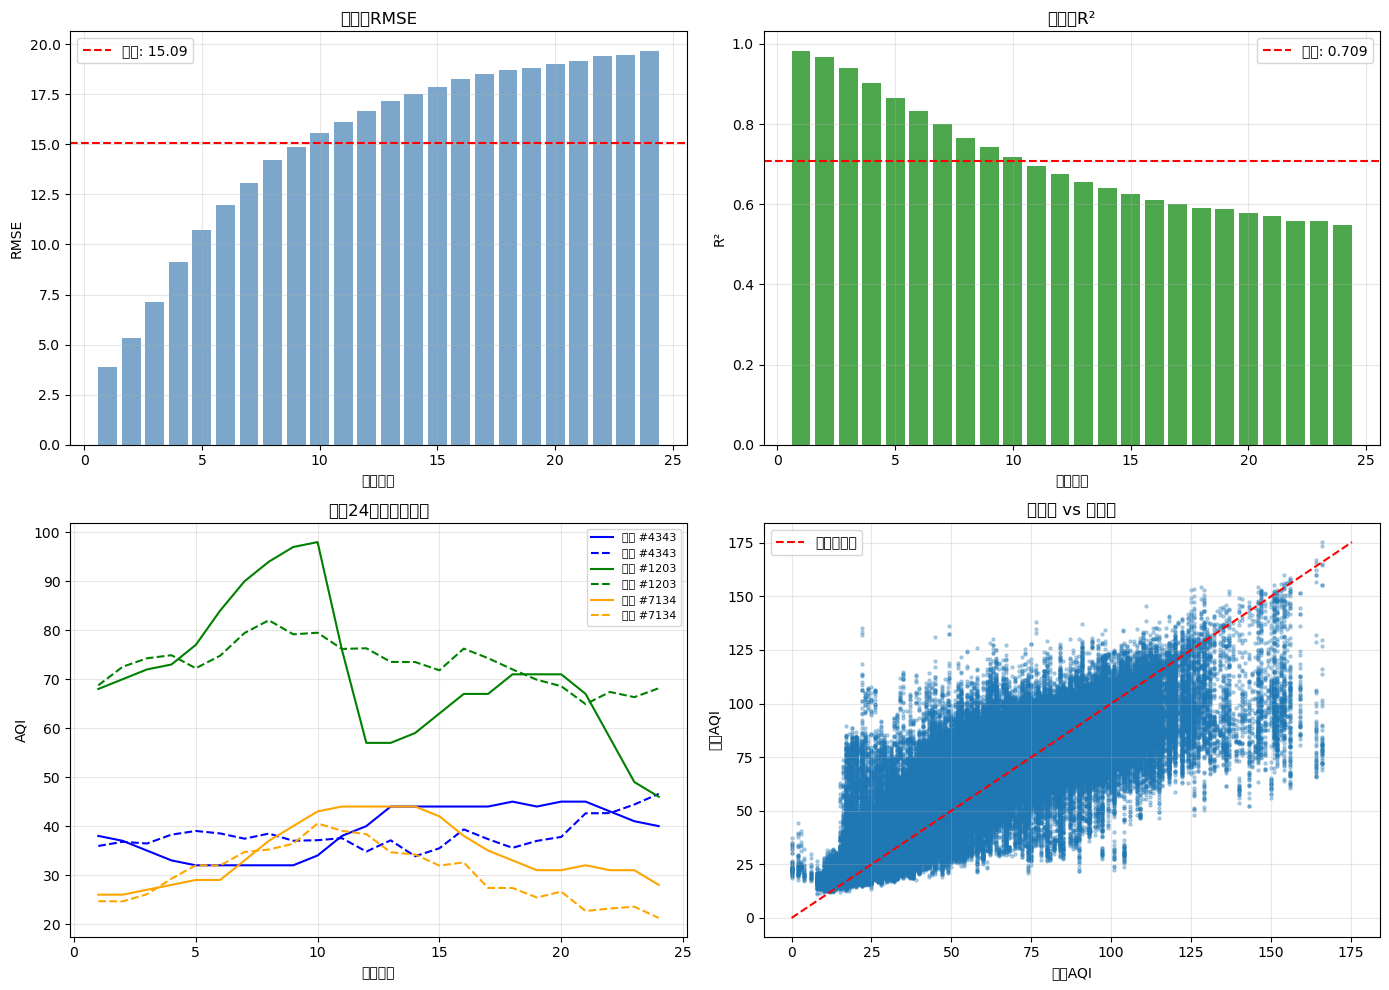

2025-12-15 18:16:50,332 - INFO - 模型已保存至 Qianjin_model.pkl



🚩 开始预测站点: Linyuan


2025-12-15 18:16:56,501 - INFO - 数据加载成功，共 204600 条记录
2025-12-15 18:16:56,559 - INFO - 预测器初始化完成，目标站点: Linyuan



📋 模型配置摘要
   预测模式: 单模型直接多输出 (1个模型 → 24维输出)
   预测窗口: 24 小时
   回溯窗口: 48 小时
   正则化级别: medium
   GPU加速: ❌ 未启用
   数据标准化: ✅ X和Y均已标准化

🎯 开始单模型多输出预测: Linyuan
   模式: 1个模型 → 24维输出


目标站点: Linyuan - 邻居站点相关性分析
邻居站点            最佳滞后(h)      最佳相关系数       零滞后相关       
----------------------------------------------------------------------
Meinong         0            0.8258       0.8258      
Qianjin         0            0.9014       0.9014      
Xiaogang        0            0.9111       0.9111      
Zuoying         0            0.8959       0.8959      


2025-12-15 18:17:02,879 - INFO - 特征工程完成，共 52 个特征，40872 条样本
2025-12-15 18:17:09,537 - INFO - 序列创建完成: X shape = (40801, 2448), y shape = (40801, 24)
2025-12-15 18:17:14,670 - INFO - 数据划分: 训练集=32640, 测试集=8161



🔄 正在标准化数据...
✅ 数据标准化完成
   X均值范围: [0.0000]
   y均值范围: [0.0481]

🚀 开始训练单模型多输出 (1个模型 → 24维输出)
   GPU加速: ❌ 未启用

⏳ 训练中...

✅ 训练完成！
   训练时间: 3790.99 秒
   子模型数量: 24

🔍 过拟合检测
训练集 RMSE: 6.6561
测试集 RMSE: 17.2093
RMSE 差距:   10.5532

训练集 R²:   0.9645
测试集 R²:   0.7422
R² 差距:     0.2224

⚠️ 警告: 检测到过拟合！建议增强正则化。

📊 站点 Linyuan 单模型多输出预测结果

【整体评估】
指标         训练集             测试集            
----------------------------------------
RMSE       6.6561          17.2093        
MAE        4.9778          11.6168        
R²         0.9645          0.7422         

【分时段评估 - 测试集】
时段              RMSE       MAE        R²        
--------------------------------------------------
短期(1-6h)        9.2684     5.9390     0.9138    
中期(7-12h)       16.6843    11.5434    0.7202    
长期(13-24h)      20.2530    14.4924    0.5870    

【逐小时评估 - 测试集（部分）】
小时       RMSE       MAE        R²        
----------------------------------------
1        4.2791     2.5581     0.9816    
6        13.1465    9.0994     0.8264    
12      

2025-12-15 19:21:36,255 - INFO - 图表已保存至 Linyuan_single_model_multi_output.png


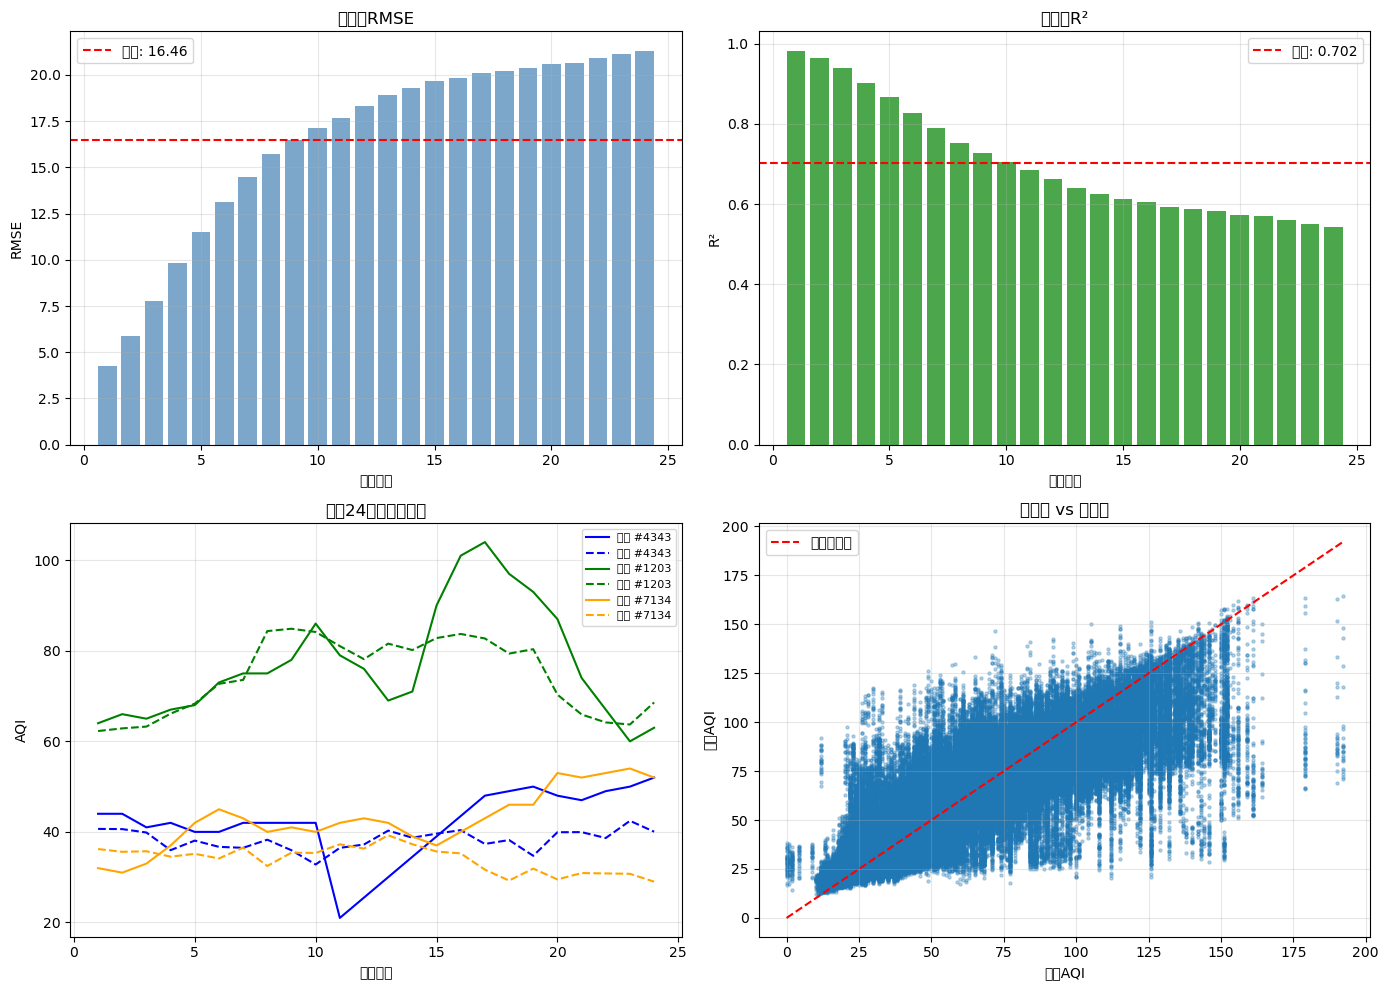

2025-12-15 19:21:44,659 - INFO - 模型已保存至 Linyuan_model.pkl



🚩 开始预测站点: Meinong


2025-12-15 19:21:46,233 - INFO - 数据加载成功，共 204600 条记录
2025-12-15 19:21:46,254 - INFO - 预测器初始化完成，目标站点: Meinong



📋 模型配置摘要
   预测模式: 单模型直接多输出 (1个模型 → 24维输出)
   预测窗口: 24 小时
   回溯窗口: 48 小时
   正则化级别: medium
   GPU加速: ❌ 未启用
   数据标准化: ✅ X和Y均已标准化

🎯 开始单模型多输出预测: Meinong
   模式: 1个模型 → 24维输出


目标站点: Meinong - 邻居站点相关性分析
邻居站点            最佳滞后(h)      最佳相关系数       零滞后相关       
----------------------------------------------------------------------
Linyuan         0            0.8258       0.8258      
Qianjin         1            0.8332       0.8318      
Xiaogang        1            0.8218       0.8200      
Zuoying         1            0.8273       0.8250      


2025-12-15 19:21:49,249 - INFO - 特征工程完成，共 52 个特征，40872 条样本
2025-12-15 19:21:52,275 - INFO - 序列创建完成: X shape = (40801, 2448), y shape = (40801, 24)
2025-12-15 19:21:54,773 - INFO - 数据划分: 训练集=32640, 测试集=8161



🔄 正在标准化数据...
✅ 数据标准化完成
   X均值范围: [0.0000]
   y均值范围: [0.0053]

🚀 开始训练单模型多输出 (1个模型 → 24维输出)
   GPU加速: ❌ 未启用

⏳ 训练中...

✅ 训练完成！
   训练时间: 3634.49 秒
   子模型数量: 24

🔍 过拟合检测
训练集 RMSE: 5.2956
测试集 RMSE: 12.6501
RMSE 差距:   7.3545

训练集 R²:   0.9652
测试集 R²:   0.7814
R² 差距:     0.1838

⚠️ 警告: 检测到过拟合！建议增强正则化。

📊 站点 Meinong 单模型多输出预测结果

【整体评估】
指标         训练集             测试集            
----------------------------------------
RMSE       5.2956          12.6501        
MAE        3.9337          8.6153         
R²         0.9652          0.7814         

【分时段评估 - 测试集】
时段              RMSE       MAE        R²        
--------------------------------------------------
短期(1-6h)        6.7371     4.3885     0.9277    
中期(7-12h)       11.9364    8.4806     0.7729    
长期(13-24h)      15.0372    10.7960    0.6393    

【逐小时评估 - 测试集（部分）】
小时       RMSE       MAE        R²        
----------------------------------------
1        3.1187     1.9739     0.9845    
6        9.3100     6.5661     0.8619    
12       

2025-12-15 20:23:54,297 - INFO - 图表已保存至 Meinong_single_model_multi_output.png


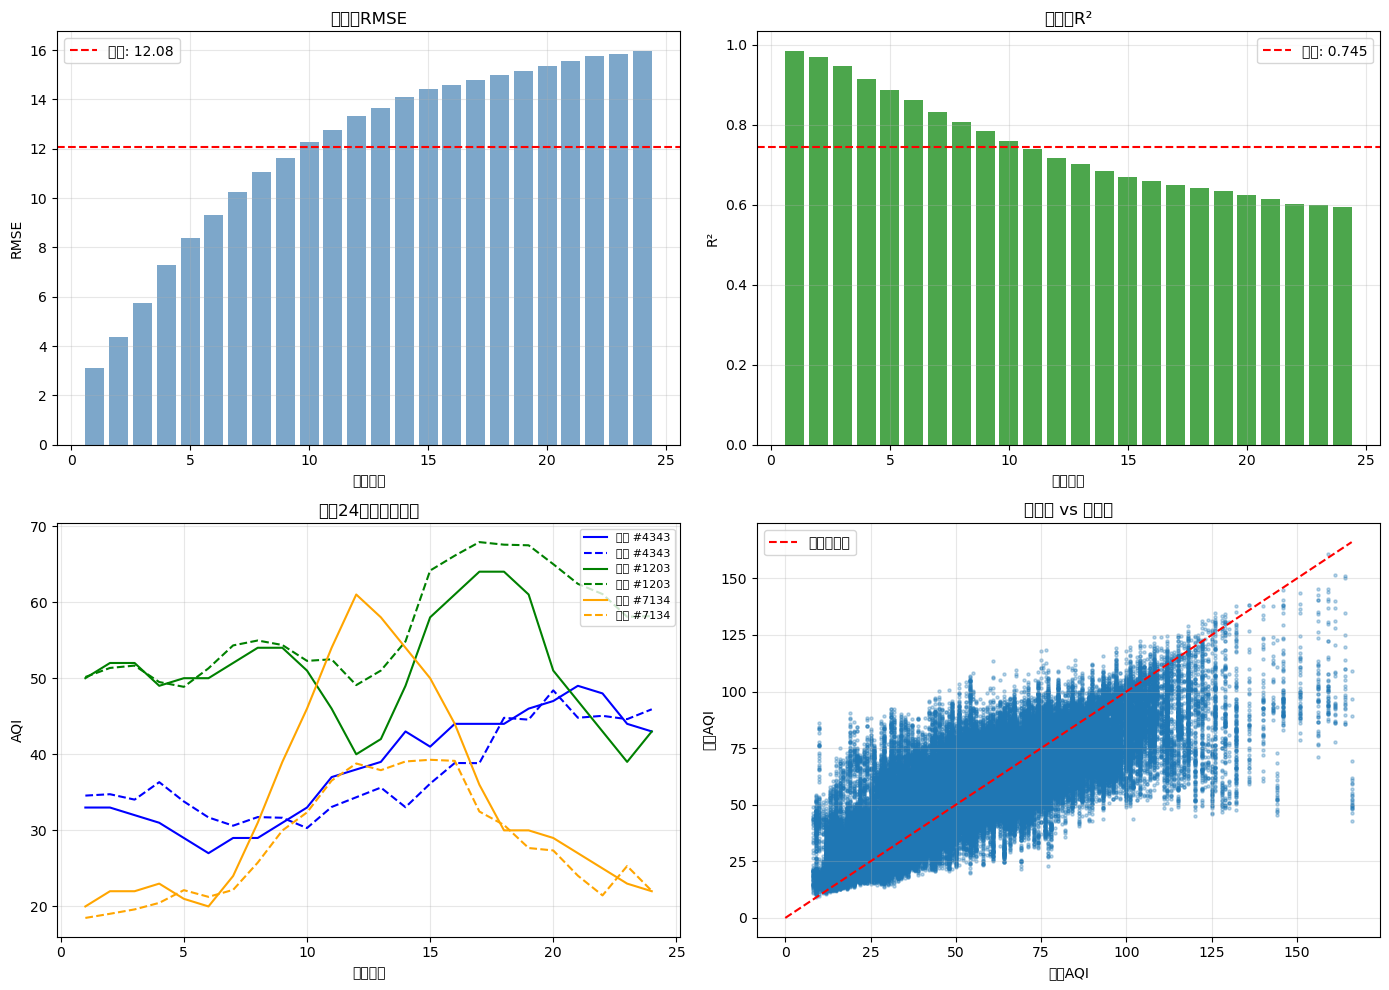

2025-12-15 20:24:05,095 - INFO - 模型已保存至 Meinong_model.pkl



🚩 开始预测站点: Xiaogang


2025-12-15 20:24:07,569 - INFO - 数据加载成功，共 204600 条记录
2025-12-15 20:24:07,793 - INFO - 预测器初始化完成，目标站点: Xiaogang



📋 模型配置摘要
   预测模式: 单模型直接多输出 (1个模型 → 24维输出)
   预测窗口: 24 小时
   回溯窗口: 48 小时
   正则化级别: medium
   GPU加速: ❌ 未启用
   数据标准化: ✅ X和Y均已标准化

🎯 开始单模型多输出预测: Xiaogang
   模式: 1个模型 → 24维输出


目标站点: Xiaogang - 邻居站点相关性分析
邻居站点            最佳滞后(h)      最佳相关系数       零滞后相关       
----------------------------------------------------------------------
Linyuan         0            0.9111       0.9111      
Meinong         0            0.8200       0.8200      
Qianjin         0            0.9421       0.9421      
Zuoying         0            0.9303       0.9303      


2025-12-15 20:24:12,951 - INFO - 特征工程完成，共 52 个特征，40872 条样本
2025-12-15 20:24:18,036 - INFO - 序列创建完成: X shape = (40801, 2448), y shape = (40801, 24)
2025-12-15 20:24:21,936 - INFO - 数据划分: 训练集=32640, 测试集=8161



🔄 正在标准化数据...
✅ 数据标准化完成
   X均值范围: [0.0000]
   y均值范围: [0.0102]

🚀 开始训练单模型多输出 (1个模型 → 24维输出)
   GPU加速: ❌ 未启用

⏳ 训练中...

✅ 训练完成！
   训练时间: 4617.56 秒
   子模型数量: 24

🔍 过拟合检测
训练集 RMSE: 6.2702
测试集 RMSE: 14.4692
RMSE 差距:   8.1989

训练集 R²:   0.9630
测试集 R²:   0.7631
R² 差距:     0.1999

⚠️ 警告: 检测到过拟合！建议增强正则化。

📊 站点 Xiaogang 单模型多输出预测结果

【整体评估】
指标         训练集             测试集            
----------------------------------------
RMSE       6.2702          14.4692        
MAE        4.6989          10.2657        
R²         0.9630          0.7631         

【分时段评估 - 测试集】
时段              RMSE       MAE        R²        
--------------------------------------------------
短期(1-6h)        7.8556     5.3822     0.9189    
中期(7-12h)       13.6816    10.0841    0.7537    
长期(13-24h)      17.1541    12.7982    0.6125    

【逐小时评估 - 测试集（部分）】
小时       RMSE       MAE        R²        
----------------------------------------
1        3.7940     2.4466     0.9811    
6        10.8604    7.9916     0.8449    
12      

2025-12-15 21:42:36,910 - INFO - 图表已保存至 Xiaogang_single_model_multi_output.png


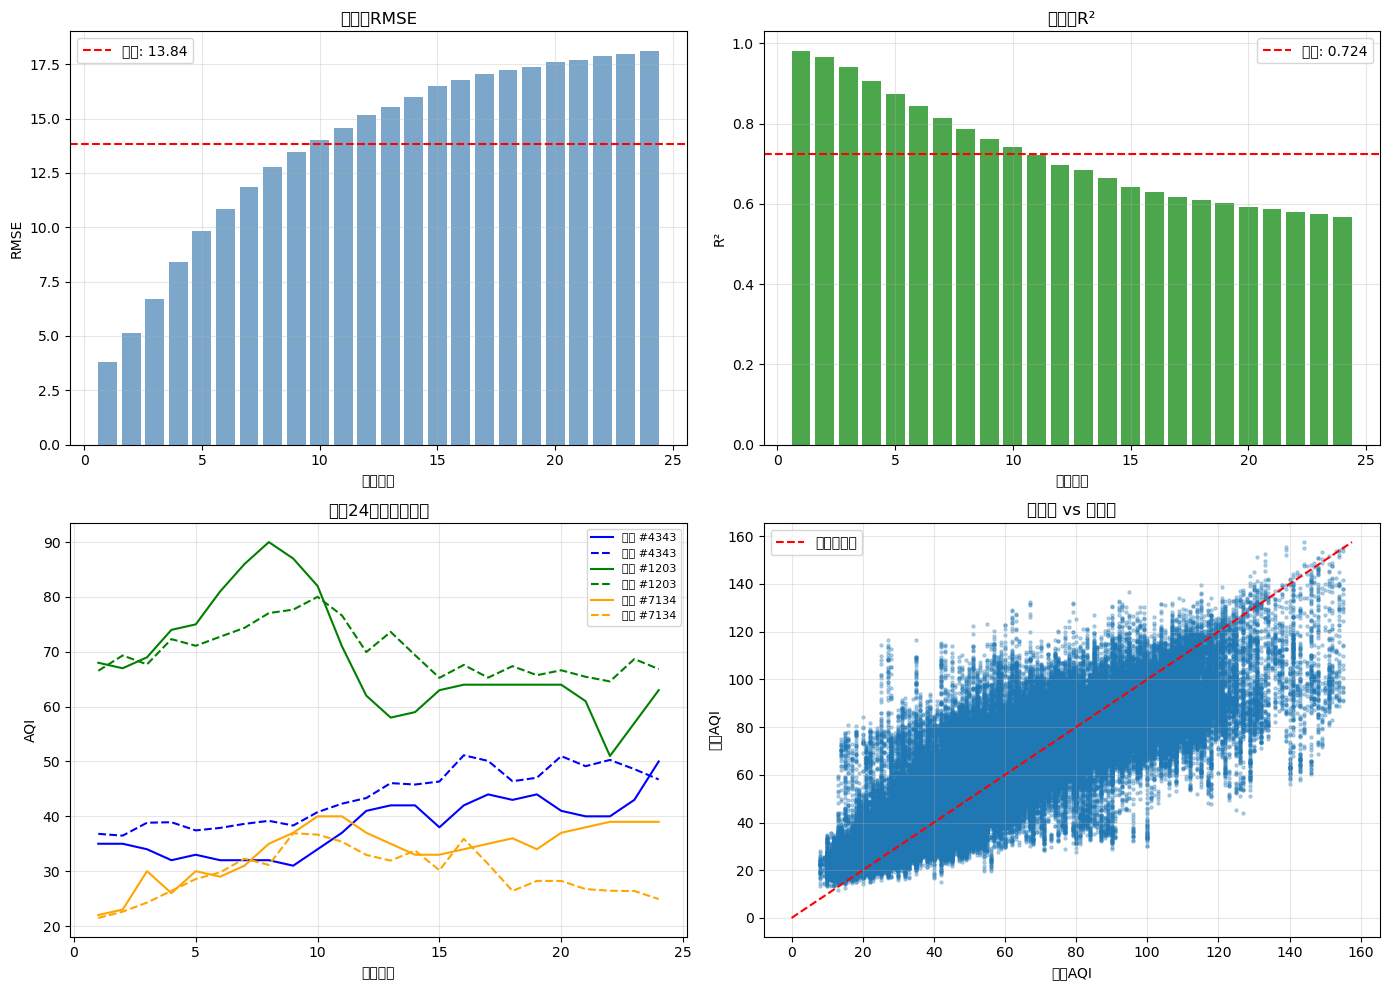

2025-12-15 21:42:47,744 - INFO - 模型已保存至 Xiaogang_model.pkl



🚩 开始预测站点: Zuoying


2025-12-15 21:42:50,025 - INFO - 数据加载成功，共 204600 条记录
2025-12-15 21:42:50,047 - INFO - 预测器初始化完成，目标站点: Zuoying



📋 模型配置摘要
   预测模式: 单模型直接多输出 (1个模型 → 24维输出)
   预测窗口: 24 小时
   回溯窗口: 48 小时
   正则化级别: medium
   GPU加速: ❌ 未启用
   数据标准化: ✅ X和Y均已标准化

🎯 开始单模型多输出预测: Zuoying
   模式: 1个模型 → 24维输出


目标站点: Zuoying - 邻居站点相关性分析
邻居站点            最佳滞后(h)      最佳相关系数       零滞后相关       
----------------------------------------------------------------------
Linyuan         0            0.8959       0.8959      
Meinong         0            0.8250       0.8250      
Qianjin         0            0.9590       0.9590      
Xiaogang        0            0.9303       0.9303      


2025-12-15 21:42:54,669 - INFO - 特征工程完成，共 52 个特征，40872 条样本
2025-12-15 21:42:58,729 - INFO - 序列创建完成: X shape = (40801, 2448), y shape = (40801, 24)
2025-12-15 21:43:03,319 - INFO - 数据划分: 训练集=32640, 测试集=8161



🔄 正在标准化数据...
✅ 数据标准化完成
   X均值范围: [0.0000]
   y均值范围: [0.0375]

🚀 开始训练单模型多输出 (1个模型 → 24维输出)
   GPU加速: ❌ 未启用

⏳ 训练中...

✅ 训练完成！
   训练时间: 3923.60 秒
   子模型数量: 24

🔍 过拟合检测
训练集 RMSE: 6.5292
测试集 RMSE: 16.2679
RMSE 差距:   9.7387

训练集 R²:   0.9631
测试集 R²:   0.7657
R² 差距:     0.1974

⚠️ 警告: 检测到过拟合！建议增强正则化。

📊 站点 Zuoying 单模型多输出预测结果

【整体评估】
指标         训练集             测试集            
----------------------------------------
RMSE       6.5292          16.2679        
MAE        4.8892          11.3212        
R²         0.9631          0.7657         

【分时段评估 - 测试集】
时段              RMSE       MAE        R²        
--------------------------------------------------
短期(1-6h)        8.5401     5.6761     0.9245    
中期(7-12h)       15.2998    11.0826    0.7577    
长期(13-24h)      19.3851    14.2631    0.6108    

【逐小时评估 - 测试集（部分）】
小时       RMSE       MAE        R²        
----------------------------------------
1        3.7107     2.3372     0.9857    
6        12.0210    8.6695     0.8504    
12       

2025-12-15 22:49:51,273 - INFO - 图表已保存至 Zuoying_single_model_multi_output.png


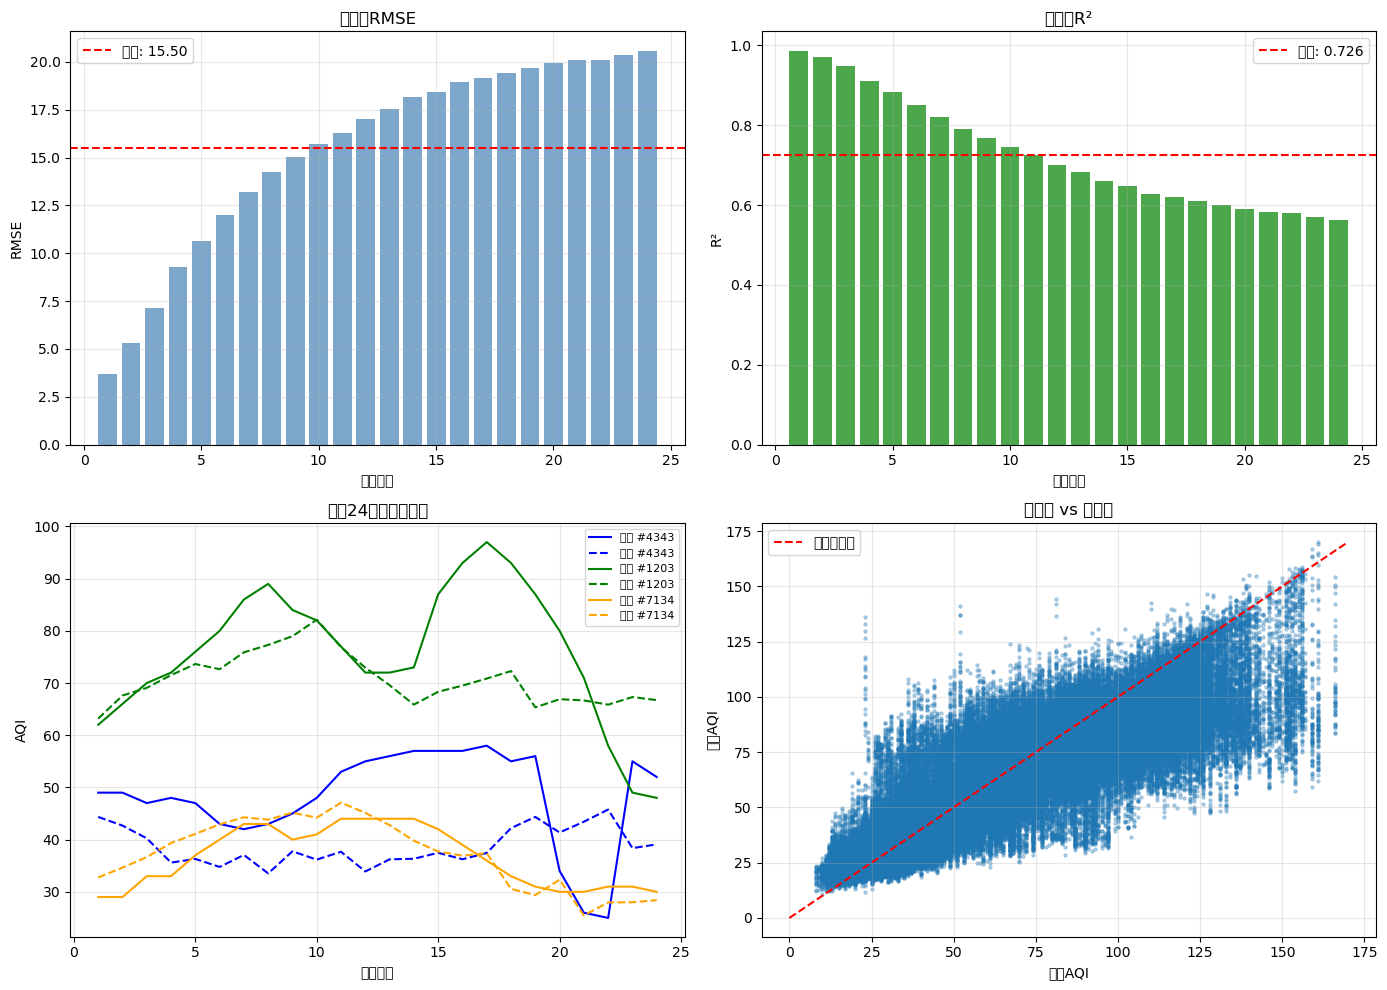

2025-12-15 22:50:02,151 - INFO - 模型已保存至 Zuoying_model.pkl



📊 五站点整体评估汇总结果：
         站点     RMSE      MAE  R2_weighted
0   Qianjin  15.7859  10.9977       0.7490
1   Linyuan  17.2093  11.6168       0.7422
2   Meinong  12.6501   8.6153       0.7814
3  Xiaogang  14.4692  10.2657       0.7631
4   Zuoying  16.2679  11.3212       0.7657


In [10]:
if __name__ == "__main__":
    run_five_sites_and_summary()

In [38]:
import os
import matplotlib.pyplot as plt
import numpy as np

def plot_five_sites_sample_fit(
    results_dict,
    sample_idx=0,
    save_dir=r"D:\jupyter picture",
    filename="five_sites_aqi_fit.png"
):
    """
    五个站点同一样本的 AQI 实际值 vs 预测值
    排版调整为2行3列（适配5个站点），并修复中文显示问题

    Parameters
    ----------
    results_dict : dict
        key   : 站点名
        value : {'y_true': array, 'y_pred': array}
    sample_idx : int
        选择测试集中的第几个样本
    save_dir : str
        图片保存目录
    filename : str
        图片文件名
    """

    # =============================
    # 解决中文显示为空白方块的问题
    # =============================
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']  # 适配Windows/macOS
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示异常

    # =============================
    # 1. 创建保存路径
    # =============================
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, filename)

    sites = list(results_dict.keys())
    n_sites = len(sites)
    hours = np.arange(1, 25)

    # =============================
    # 2. 创建2行3列的子图（适配5个站点，多余子图隐藏）
    # =============================
    rows, cols = 2, 3
    fig, axes = plt.subplots(
        rows, cols,
        figsize=(18, 10),  # 调整尺寸匹配目标排版
        sharex=True
    )
    axes = axes.flatten()  # 把2x3的数组展平为一维，方便遍历

    # =============================
    # 3. 每个站点画一个子图
    # =============================
    for i, (ax, site) in enumerate(zip(axes[:n_sites], sites)):
        y_true = results_dict[site]['y_true'][sample_idx]
        y_pred = results_dict[site]['y_pred'][sample_idx]

        ax.plot(
            hours, y_true,
            linewidth=2,
            marker='o',
            label='实际 AQI'
        )
        ax.plot(
            hours, y_pred,
            linewidth=2,
            linestyle='--',
            marker='s',
            label='预测 AQI'
        )

        ax.set_title(f'站点：{site}', fontsize=12)
        ax.set_ylabel('AQI')
        ax.grid(alpha=0.3)
        ax.legend()

    # 隐藏第6个多余的子图
    for ax in axes[n_sites:]:
        ax.axis('off')

    # =============================
    # 4. 总标题 + 布局调整
    # =============================
    fig.suptitle(
        '5个站点24小时AQI实际值与预测值拟合对比',
        fontsize=15,
        y=0.98
    )
    axes[-2].set_xlabel('预测时长（小时）')  # 最后一行子图统一加x轴标签

    plt.tight_layout(rect=[0.02, 0.02, 0.98, 0.95])

    # =============================
    # 5. 保存图片到本地
    # =============================
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

    print(f"✅ 图像已保存至：{save_path}")


In [39]:
if __name__ == "__main__":

    DATA_PATH = 'D:/Data/kaohsiung_5sites_final.csv'
    SITES = ['Qianjin', 'Linyuan', 'Meinong', 'Xiaogang', 'Zuoying']

    plot_five_sites_from_saved_models(
        data_path=DATA_PATH,
        sites=SITES,
        model_dir='.',
        sample_idx=0
    )


📂 加载站点模型: Qianjin


2025-12-16 00:56:24,370 - INFO - 数据加载成功，共 204600 条记录
2025-12-16 00:56:24,390 - INFO - 预测器初始化完成，目标站点: Qianjin



📋 模型配置摘要
   预测模式: 单模型直接多输出 (1个模型 → 24维输出)
   预测窗口: 24 小时
   回溯窗口: 48 小时
   正则化级别: strong
   GPU加速: ❌ 未启用
   数据标准化: ✅ X和Y均已标准化


2025-12-16 00:56:25,222 - INFO - 模型已从 ./Qianjin_model.pkl 加载



目标站点: Qianjin - 邻居站点相关性分析
邻居站点            最佳滞后(h)      最佳相关系数       零滞后相关       
----------------------------------------------------------------------
Linyuan         0            0.9014       0.9014      
Meinong         0            0.8318       0.8318      
Xiaogang        0            0.9421       0.9421      
Zuoying         0            0.9590       0.9590      


...


📋 模型配置摘要
   预测模式: 单模型直接多输出 (1个模型 → 24维输出)
   预测窗口: 24 小时
   回溯窗口: 48 小时
   正则化级别: strong
   GPU加速: ❌ 未启用
   数据标准化: ✅ X和Y均已标准化


2025-12-16 00:58:06,015 - INFO - 模型已从 ./Zuoying_model.pkl 加载



目标站点: Zuoying - 邻居站点相关性分析
邻居站点            最佳滞后(h)      最佳相关系数       零滞后相关       
----------------------------------------------------------------------
Linyuan         0            0.8959       0.8959      
Meinong         0            0.8250       0.8250      
Qianjin         0            0.9590       0.9590      
Xiaogang        0            0.9303       0.9303      


2025-12-16 00:58:08,815 - INFO - 特征工程完成，共 52 个特征，40872 条样本
2025-12-16 00:58:11,499 - INFO - 序列创建完成: X shape = (40801, 2448), y shape = (40801, 24)


✅ 图像已保存至：D:\jupyter picture\five_sites_aqi_fit.png


In [40]:
import pandas as pd
from sklearn.metrics import r2_score

SITES = ['Qianjin', 'Linyuan', 'Meinong', 'Xiaogang', 'Zuoying']

records = []

for site in SITES:
    df = pd.read_csv(f'{site}_hourly_metrics.csv')

    r2_1_6   = df.loc[df['hour'].between(1, 6), 'r2'].mean()
    r2_7_12  = df.loc[df['hour'].between(7, 12), 'r2'].mean()
    r2_13_18 = df.loc[df['hour'].between(13, 18), 'r2'].mean()
    r2_19_24 = df.loc[df['hour'].between(19, 24), 'r2'].mean()

    records.append({
        '站点': site,
        '1-6h': round(r2_1_6, 4),
        '7-12h': round(r2_7_12, 4),
        '13-18h': round(r2_13_18, 4),
        '19-24h': round(r2_19_24, 4)
    })

df_r2_4period = pd.DataFrame(records)
print(df_r2_4period)

df_r2_4period.to_csv(
    'five_sites_four_period_r2.csv',
    index=False,
    encoding='utf-8-sig'
)


         站点    1-6h   7-12h  13-18h  19-24h
0   Qianjin  0.9152  0.7327  0.6206  0.5671
1   Linyuan  0.9137  0.7201  0.6103  0.5637
2   Meinong  0.9277  0.7729  0.6676  0.6109
3  Xiaogang  0.9189  0.7537  0.6411  0.5838
4   Zuoying  0.9245  0.7577  0.6412  0.5805


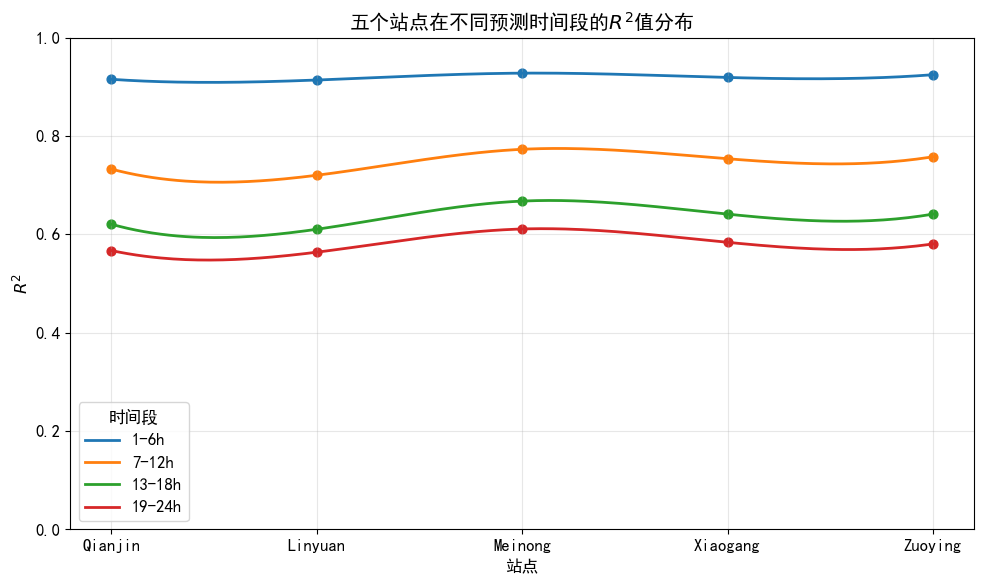

✅ 图已保存至：D:\jupyter picture\R2_lineplot_smooth.png


In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.interpolate import make_interp_spline
import os

# -----------------------------
# 1. 准备数据
# -----------------------------
data = {
    '站点': ['Qianjin', 'Linyuan', 'Meinong', 'Xiaogang', 'Zuoying'],
    '1-6h': [0.9152, 0.9137, 0.9277, 0.9189, 0.9245],
    '7-12h': [0.7327, 0.7201, 0.7729, 0.7537, 0.7577],
    '13-18h': [0.6206, 0.6103, 0.6676, 0.6411, 0.6412],
    '19-24h': [0.5671, 0.5637, 0.6109, 0.5838, 0.5805]
}
df_r2 = pd.DataFrame(data)

# -----------------------------
# 2. 创建保存目录
# -----------------------------
save_dir = r"D:\jupyter picture"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "R2_lineplot_smooth.png")

# -----------------------------
# 3. 字体设置（中文不显示方块）
# -----------------------------
plt.rcParams['font.sans-serif'] = ['SimHei']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False    # 负号正常显示
plt.rcParams['font.size'] = 12

# -----------------------------
# 4. 绘制平滑折线
# -----------------------------
plt.figure(figsize=(10,6))

time_periods = ['1-6h','7-12h','13-18h','19-24h']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # 蓝 橙 绿 红

x = np.arange(len(df_r2['站点']))  # x = 0,1,2,3,4

for period, color in zip(time_periods, colors):
    y = df_r2[period].values

    # -----------------------------
    # 平滑曲线
    # -----------------------------
    x_new = np.linspace(x.min(), x.max(), 200)  # 200 个点
    spl = make_interp_spline(x, y, k=3)        # 三次 B 样条
    y_smooth = spl(x_new)

    plt.plot(
        x_new, y_smooth,
        linewidth=2,
        color=color,
        label=period
    )
    plt.scatter(x, y, color=color, s=40)  # 保留原始点

# -----------------------------
# 坐标轴 & 网格
# -----------------------------
plt.xticks(x, df_r2['站点'])  # 横轴显示站点名
plt.xlabel('站点')
plt.ylabel('$R^2$')
plt.title('五个站点在不同预测时间段的$R^2$值分布')
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend(title='时间段')
plt.tight_layout()

# -----------------------------
# 5. 保存图片
# -----------------------------
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ 图已保存至：{save_path}")



In [5]:

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calc_four_period_metrics(y_true, y_pred):
    periods = {
        '1-6h':   (0, 6),
        '7-12h':  (6, 12),
        '13-18h': (12, 18),
        '19-24h': (18, 24)
    }

    rows = []
    for name, (start, end) in periods.items():
        yt = y_true[:, start:end].flatten()
        yp = y_pred[:, start:end].flatten()

        rows.append({
            '时间段': name,
            'RMSE': np.sqrt(mean_squared_error(yt, yp)),
            'MAE': mean_absolute_error(yt, yp),
            'R²': r2_score(yt, yp)
        })

    return rows


In [6]:
def evaluate_five_sites_four_period(DATA_PATH):
    SITES = ['Qianjin', 'Linyuan', 'Meinong', 'Xiaogang', 'Zuoying']
    records = []

    for site in SITES:
        print(f'📂 处理站点: {site}')

        predictor = SingleModelMultiOutputPredictor(
            data_path=DATA_PATH,
            target_site=site
        )

        # ✅ 加载已训练模型
        predictor.load_model(f'{site}_model.pkl')

        # 只做特征 & 测试集预测（不训练）
        lag_config, _ = predictor.analyze_correlations()
        df_feat = predictor.prepare_features(lag_config)
        X, y = predictor.create_sequences(df_feat)

        split_idx = int(len(X) * (1 - predictor.config.test_size))
        X_test = X[split_idx:]
        y_test = y[split_idx:]

        X_test_scaled = predictor.scaler_X.transform(X_test)
        y_pred = predictor.predict(X_test_scaled)

        site_metrics = calc_four_period_metrics(y_test, y_pred)

        for row in site_metrics:
            row['站点'] = site
            records.append(row)

    return pd.DataFrame(records)


In [7]:
df_4period = evaluate_five_sites_four_period(
    DATA_PATH='D:/Data/kaohsiung_5sites_final.csv'
)

print(df_4period)


📂 处理站点: Qianjin


NameError: name 'SingleModelMultiOutputPredictor' is not defined